# QQQI / QQQ / TQQQ v4.2 — State-2 Tail and Execution Diagnostics

This notebook evaluates the frozen v4.2 research baseline. It does **not** change signals, weights, thresholds, or the official 10 bps transaction-cost assumption.

Questions:

1. Are leveraged-state tail losses dominated by intraday deterioration or close-to-next-open gaps?
2. Were warning conditions observable before the worst losses?
3. How sensitive is v4.2 to one-session execution delays and additional slippage stress?
4. Does the pre-registered gate permit a continuous state-2 volatility-budget challenger?


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("artifacts/evidence/qqqi_qqq_tqqq_v4_2_state2_tail_diagnostics")
summary = json.loads((ROOT / "state_2_tail_summary.json").read_text(encoding="utf-8"))
episodes = pd.read_csv(ROOT / "state_2_episodes.csv", parse_dates=["start_date", "end_date", "trough_date", "worst_date"])
episode_summary = pd.read_csv(ROOT / "state_2_episode_summary.csv")
tail_days = pd.read_csv(ROOT / "state_2_top_tail_days.csv", parse_dates=["date"])
execution = pd.read_csv(ROOT / "execution_robustness.csv", index_col=0)

summary["economic_sample"], summary["research_gate"]

({'end_date': '2026-07-30', 'observations': 627, 'start_date': '2024-01-30'},
 {'eligible_for_continuous_state2_volatility_budget': False,
  'gates': {'gradual_episode_rate_above_minimum': False,
   'observable_warning_rate_above_minimum': False,
   'overnight_loss_share_below_limit': True},
  'measured': {'gradual_episode_rate': 0.33333333333333337,
   'risk_reduction_delay_cagr_delta': -0.0009745147253006348,
   'top_tail_overnight_loss_share': 0.2732763584006705,
   'top_tail_previous_close_warning_rate': 0.0,
   'top_tail_same_close_exit_signal_rate': 0.6},
  'next_direction': 'retain_v4_2_and_continue_prospective_monitoring',
  'thresholds': {'eligible_direction': 'design_one_continuous_state2_volatility_budget_challenger',
   'ineligible_execution_direction': 'study_exit_execution_reliability_before_new_risk_budget',
   'ineligible_gap_direction': 'do_not_add_close_based_scaling; prioritize_gap_risk_and_low_risk_variant',
   'max_overnight_loss_share': 0.5,
   'max_risk_reduction

## 1. State-2 episode summary

In [2]:
episode_summary.T

,0
episodes,12.000000
sessions,129.000000
mean_episode_net_return,0.047063
negative_episode_rate,0.416667
mean_episode_max_drawdown,-0.048084
worst_episode_net_return,-0.078534
abrupt_or_gap_dominated_rate,0.666667
mean_overnight_loss_share,0.266236
prior_warning_rate,0.000000
same_close_exit_signal_rate,0.750000


In [3]:
episodes[[
    "episode_id", "start_date", "end_date", "sessions", "net_return",
    "max_drawdown", "overnight_loss_share", "worst_day_share_of_mae",
    "prior_close_warning_before_worst_day",
    "same_close_exit_signal_on_worst_day", "tail_mechanism",
]].sort_values("net_return")

,episode_id,start_date,end_date,sessions,net_return,max_drawdown,overnight_loss_share,worst_day_share_of_mae,prior_close_warning_before_worst_day,same_close_exit_signal_on_worst_day,tail_mechanism
3,4,2024-09-03,2024-09-03,1,-0.078534,-0.078534,0.211158,1.000000,False,True,abrupt_or_gap_dominated
0,1,2024-08-22,2024-08-22,1,-0.031769,-0.031769,-0.000000,1.000000,False,True,abrupt_or_gap_dominated
1,2,2024-08-26,2024-08-26,1,-0.031613,-0.031613,0.287304,1.000000,False,True,abrupt_or_gap_dominated
2,3,2024-08-28,2024-08-28,1,-0.017797,-0.017797,-0.000000,1.000000,False,True,abrupt_or_gap_dominated
5,6,2024-09-20,2024-10-01,8,-0.011793,-0.065890,0.179567,1.000000,False,True,abrupt_or_gap_dominated
10,11,2026-05-15,2026-05-15,1,0.002954,0.000000,-0.000000,0.000000,False,True,gradual_or_distributed
4,5,2024-09-16,2024-09-16,1,0.014591,0.000000,0.000000,0.000000,False,True,gradual_or_distributed
6,7,2024-11-08,2024-12-18,28,0.021960,-0.088067,0.289350,0.845241,False,True,abrupt_or_gap_dominated
7,8,2025-05-13,2025-05-23,9,0.028468,-0.070562,0.881844,1.000000,False,False,abrupt_or_gap_dominated
11,12,2026-05-19,2026-06-05,13,0.051429,-0.102868,0.434336,0.000000,False,True,gradual_or_distributed


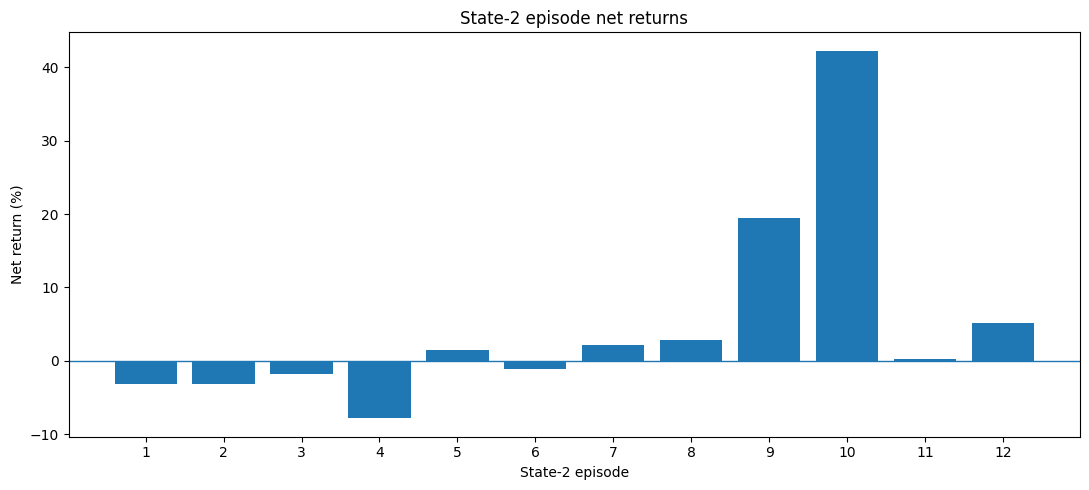

In [4]:
plot_data = episodes.sort_values("start_date")
plt.figure(figsize=(11, 5))
plt.bar(plot_data["episode_id"].astype(str), plot_data["net_return"] * 100)
plt.axhline(0, linewidth=1)
plt.xlabel("State-2 episode")
plt.ylabel("Net return (%)")
plt.title("State-2 episode net returns")
plt.tight_layout()
plt.show()

## 2. Worst state-2 sessions and loss decomposition

In [5]:
tail_days[[
    "date", "net_return", "intraday_contribution", "overnight_contribution",
    "previous_close_warning", "same_close_exit_signal", "decision_reason",
    "vix_close", "vxn_close", "qqq_below_ma20",
]]

,date,net_return,intraday_contribution,overnight_contribution,previous_close_warning,same_close_exit_signal,decision_reason,vix_close,vxn_close,qqq_below_ma20
0,2024-09-03,-0.078534,-0.060768,-0.016266,False,True,defensive_price_or_vix_stress,20.719999,23.590000,True
1,2025-07-31,-0.067185,-0.040551,-0.026635,False,False,hold,16.719999,19.230000,False
2,2024-12-18,-0.066914,-0.086959,0.020045,False,True,defensive_price_or_vix_stress,27.620001,27.629999,True
3,2026-06-05,-0.047501,-0.086899,0.039397,False,True,defensive_price_or_vix_stress,21.510000,30.469999,True
4,2024-11-14,-0.044091,-0.015637,-0.028455,False,False,hold,14.310000,17.700001,False
5,2026-06-03,-0.039969,-0.010617,-0.029352,False,False,hold,16.059999,23.840000,False
6,2024-10-01,-0.037693,-0.032972,-0.004721,False,True,exit_partial_tqqq_vix_vxn_or_ma20,19.260000,21.670000,False
7,2025-05-22,-0.037421,0.001596,-0.039017,False,False,hold,20.280001,23.629999,False
8,2024-08-22,-0.031769,-0.051267,0.020998,False,True,exit_partial_tqqq_vix_vxn_or_ma20,17.549999,22.830000,False
9,2024-08-26,-0.031613,-0.021461,-0.008652,False,True,exit_partial_tqqq_vix_vxn_or_ma20,16.150000,21.570000,False


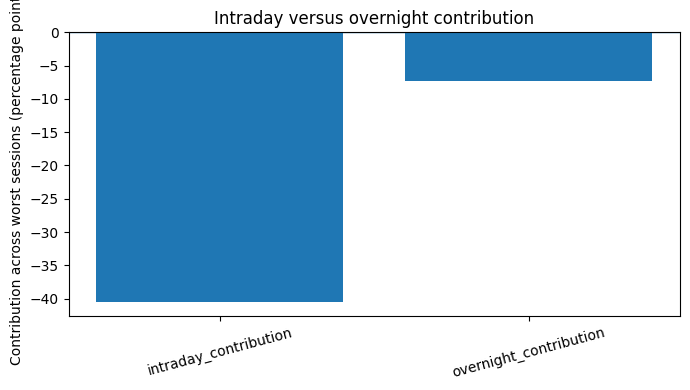

In [6]:
components = tail_days[["intraday_contribution", "overnight_contribution"]].sum() * 100
plt.figure(figsize=(7, 4))
plt.bar(components.index, components.values)
plt.axhline(0, linewidth=1)
plt.ylabel("Contribution across worst sessions (percentage points)")
plt.title("Intraday versus overnight contribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Execution robustness

In [7]:
execution[[
    "total_return", "cagr", "sharpe", "sortino", "max_drawdown", "calmar",
    "turnover_units", "transaction_cost_paid",
    "cagr_delta_vs_baseline", "max_drawdown_delta_vs_baseline",
]]

,total_return,cagr,sharpe,sortino,max_drawdown,calmar,turnover_units,transaction_cost_paid,cagr_delta_vs_baseline,max_drawdown_delta_vs_baseline
strategy,,,,,,,,,,
all_transitions_delay_1,1.137416,0.357022,1.342121,1.968947,-0.271548,1.314764,34.0,0.0340,0.026448,-0.029414
baseline,1.035264,0.330574,1.243717,1.801463,-0.242134,1.365249,55.0,0.0550,0.000000,0.000000
baseline_plus_10bps,0.926210,0.301447,1.156616,1.668471,-0.258602,1.165677,55.0,0.1100,-0.029127,-0.016468
baseline_plus_20bps,0.822857,0.272917,1.069162,1.536053,-0.280723,0.972194,55.0,0.1650,-0.057657,-0.038588
baseline_plus_5bps,0.980006,0.315935,1.200219,1.734904,-0.247300,1.277535,55.0,0.0825,-0.014639,-0.005166
risk_increase_delay_1,1.109981,0.349995,1.336440,1.969115,-0.242282,1.444577,37.0,0.0370,0.019421,-0.000147
risk_reduction_delay_1,1.031557,0.329599,1.223440,1.759547,-0.271407,1.214410,43.0,0.0430,-0.000975,-0.029272


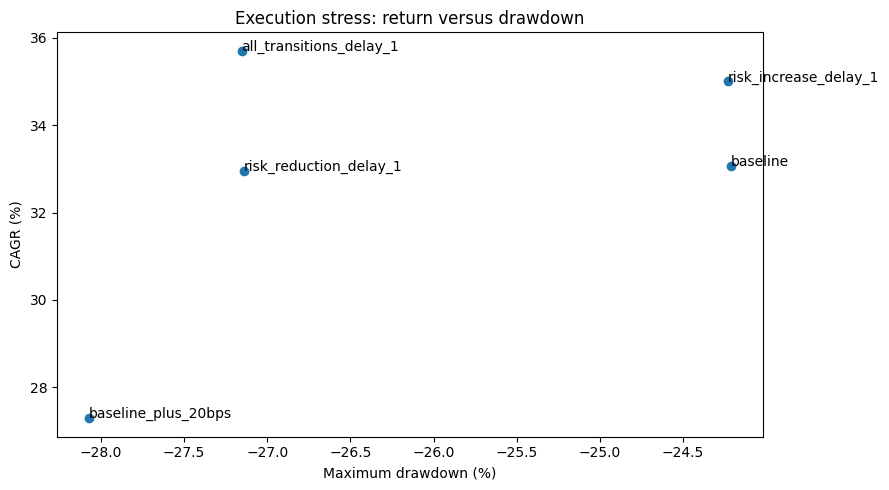

In [8]:
plot_exec = execution.loc[[
    "baseline", "all_transitions_delay_1", "risk_increase_delay_1",
    "risk_reduction_delay_1", "baseline_plus_20bps"
]]
plt.figure(figsize=(9, 5))
plt.scatter(plot_exec["max_drawdown"] * 100, plot_exec["cagr"] * 100)
for name, row in plot_exec.iterrows():
    plt.annotate(name, (row["max_drawdown"] * 100, row["cagr"] * 100))
plt.xlabel("Maximum drawdown (%)")
plt.ylabel("CAGR (%)")
plt.title("Execution stress: return versus drawdown")
plt.tight_layout()
plt.show()

## 4. Pre-registered research gate

In [9]:
gate = summary["research_gate"]
pd.Series(gate["measured"], name="measured").to_frame().join(
    pd.Series(gate["gates"], name="passed")
)

,measured,passed
gradual_episode_rate,0.333333,NaN
risk_reduction_delay_cagr_delta,-0.000975,NaN
top_tail_overnight_loss_share,0.273276,NaN
top_tail_previous_close_warning_rate,0.000000,NaN
top_tail_same_close_exit_signal_rate,0.600000,NaN


In [10]:
print("Eligible for continuous state-2 volatility budget:",
      gate["eligible_for_continuous_state2_volatility_budget"])
print("Next direction:", gate["next_direction"])

Eligible for continuous state-2 volatility budget: False
Next direction: retain_v4_2_and_continue_prospective_monitoring
